In [52]:
!pip install seaborn xgboost -q

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.metrics import confusion_matrix, classification_report, roc_curve, auc
from xgboost import XGBClassifier

In [53]:
!wget -q https://raw.githubusercontent.com/defcom17/NSL_KDD/master/KDDTrain%2B.txt
!wget -q https://raw.githubusercontent.com/defcom17/NSL_KDD/master/KDDTest%2B.txt

In [71]:
columns = [
'duration','protocol_type','service','flag','src_bytes','dst_bytes','land','wrong_fragment','urgent',
'hot','num_failed_logins','logged_in','num_compromised','root_shell','su_attempted','num_root',
'num_file_creations','num_shells','num_access_files','num_outbound_cmds','is_host_login',
'is_guest_login','count','srv_count','serror_rate','srv_serror_rate','rerror_rate','srv_rerror_rate',
'same_srv_rate','diff_srv_rate','srv_diff_host_rate','dst_host_count','dst_host_srv_count',
'dst_host_same_srv_rate','dst_host_diff_srv_rate','dst_host_same_src_port_rate',
'dst_host_srv_diff_host_rate','dst_host_serror_rate','dst_host_srv_serror_rate',
'dst_host_rerror_rate','dst_host_srv_rerror_rate','label', 'difficulty_score'
]

In [73]:
train = pd.read_csv('KDDTrain+.txt', names=columns, dtype={'label': str})
test  = pd.read_csv('KDDTest+.txt',  names=columns, dtype={'label': str})

# Drop the 'difficulty_score' column as it's not needed for classification
train = train.drop('difficulty_score', axis=1)
test = test.drop('difficulty_score', axis=1)

In [75]:
print("Unique labels in train before conversion:")
print(train['label'].value_counts())

train['label'] = (train['label'] != 'normal').astype(int)
test['label']  = (test['label']  != 'normal').astype(int)

print("Unique labels in train after conversion:")
print(train['label'].value_counts())

Unique labels in train before conversion:
label
normal             67343
neptune            41214
satan               3633
ipsweep             3599
portsweep           2931
smurf               2646
nmap                1493
back                 956
teardrop             892
warezclient          890
pod                  201
guess_passwd          53
buffer_overflow       30
warezmaster           20
land                  18
imap                  11
rootkit               10
loadmodule             9
ftp_write              8
multihop               7
phf                    4
perl                   3
spy                    2
Name: count, dtype: int64
Unique labels in train after conversion:
label
0    67343
1    58630
Name: count, dtype: int64


In [76]:
train = pd.get_dummies(train)
test  = pd.get_dummies(test)

# Align columns so train & test match
train, test = train.align(test, join='left', axis=1, fill_value=0)

In [77]:
X_train = train.drop('label', axis=1)
y_train = train['label']

X_test  = test.drop('label', axis=1)
y_test  = test['label']

In [78]:
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test  = scaler.transform(X_test)

In [79]:
model = XGBClassifier(
    n_estimators=120,
    max_depth=5,
    learning_rate=0.1,
    subsample=0.8,
    eval_metric='logloss'
)

print(f"Unique values in y_train: {y_train.unique()}")
print(f"Value counts for y_train:\n{y_train.value_counts()}")

model.fit(X_train, y_train)

Unique values in y_train: [0 1]
Value counts for y_train:
label
0    67343
1    58630
Name: count, dtype: int64


XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='logloss',
              feature_types=None, feature_weights=None, gamma=None,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.1, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=5, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=120, n_jobs=None,
              num_parallel_tree=None, ...)

Accuracy: 0.8041
Precision: 0.9691
Recall: 0.6774
F1-Score: 0.7974


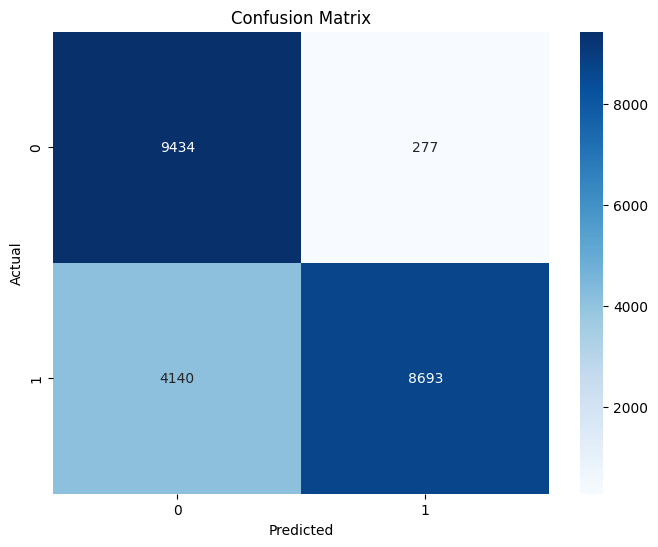


Classification Report:
              precision    recall  f1-score   support

           0       0.70      0.97      0.81      9711
           1       0.97      0.68      0.80     12833

    accuracy                           0.80     22544
   macro avg       0.83      0.82      0.80     22544
weighted avg       0.85      0.80      0.80     22544



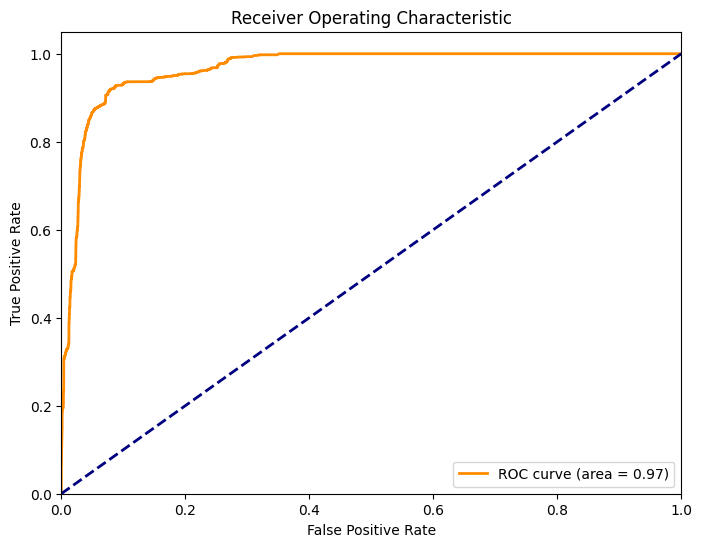

In [80]:
# Make predictions on the test set
y_pred = model.predict(X_test)
y_proba = model.predict_proba(X_test)[:, 1]

# Evaluate model performance
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print(f"Accuracy: {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"F1-Score: {f1:.4f}")

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

# Classification Report
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

# ROC Curve
fpr, tpr, thresholds = roc_curve(y_test, y_proba)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (area = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic')
plt.legend(loc="lower right")
plt.show()

In [ ]:
print(f"Accuracy: {accuracy:.4f}")